> ## Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer # for impute missing value 

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score




> ### Load the dataset

In [2]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.shape

(20640, 10)

> ## Exploratory Data Analysis

In [4]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

> ### Basic dataset overview

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
print("Missing value per column")
df.isnull().sum()

Missing value per column


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
target = "median_house_value"
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [8]:
print("Target column :",target)
print("Numerical columns : ",numerical_cols)
print("Categorical columns : ",categorical_cols)

Target column : median_house_value
Numerical columns :  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns :  ['ocean_proximity']


> ### Checking duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# descriptive stat
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


> ### Visualization

In [11]:
df[categorical_cols].value_counts()

ocean_proximity
<1H OCEAN          9136
INLAND             6551
NEAR OCEAN         2658
NEAR BAY           2290
ISLAND                5
Name: count, dtype: int64

C:\Users\Din islam\AppData\Local\Temp\ipykernel_25832\533474017.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=col, data=df, palette='viridis')


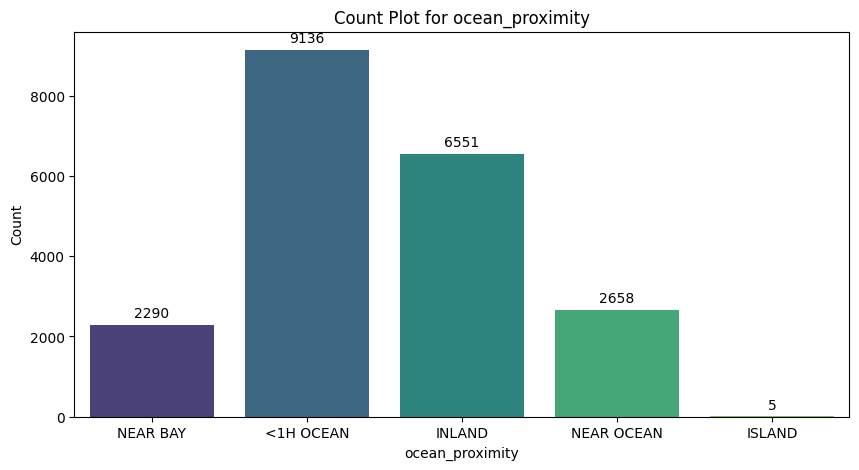

In [12]:
# Visualization of categorical column
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(x=col, data=df, palette='viridis')
    
    # Add labels above each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
    
    plt.title(f'Count Plot for {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

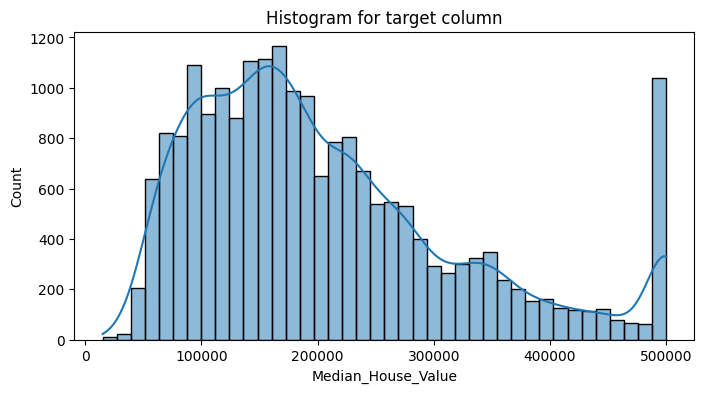

In [13]:
# target column distribution
plt.figure(figsize=(8,4))
sns.histplot(x=df['median_house_value'],kde=True,bins=40)
plt.title("Histogram for target column")
plt.xlabel("Median_House_Value")
plt.show()

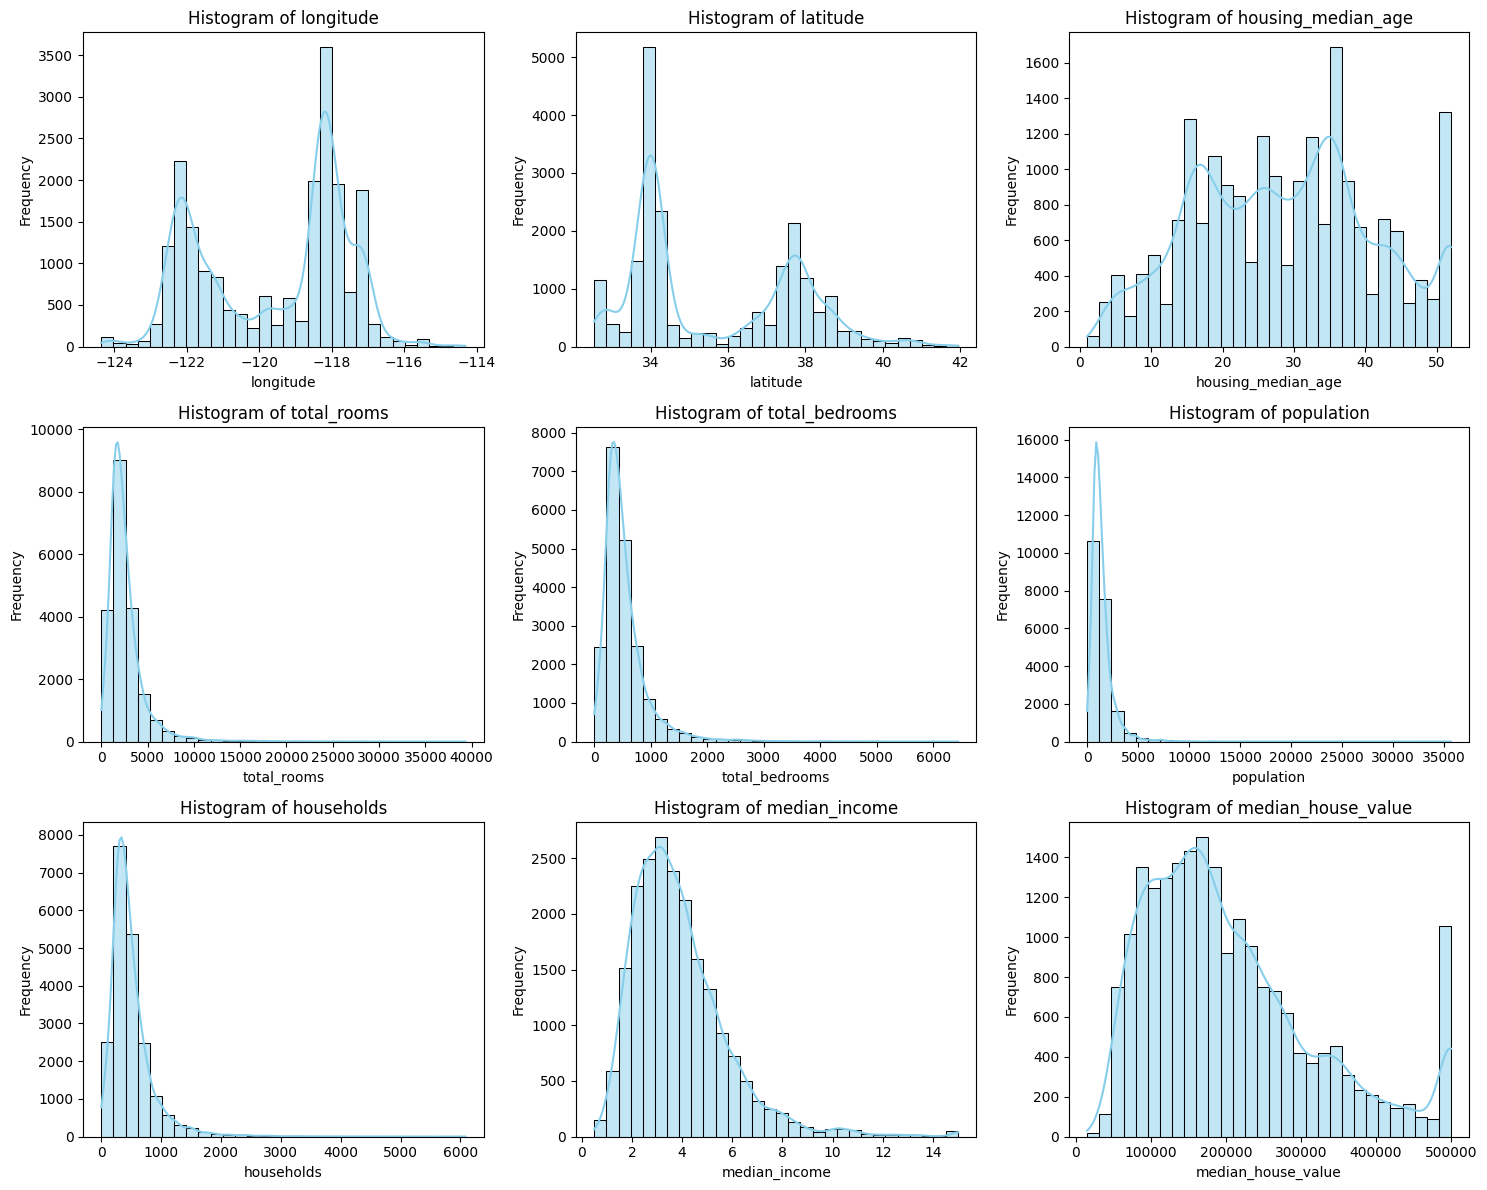

In [14]:
# Create 3x3 subplots for numerical columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # flatten to easily iterate

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Histogram of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


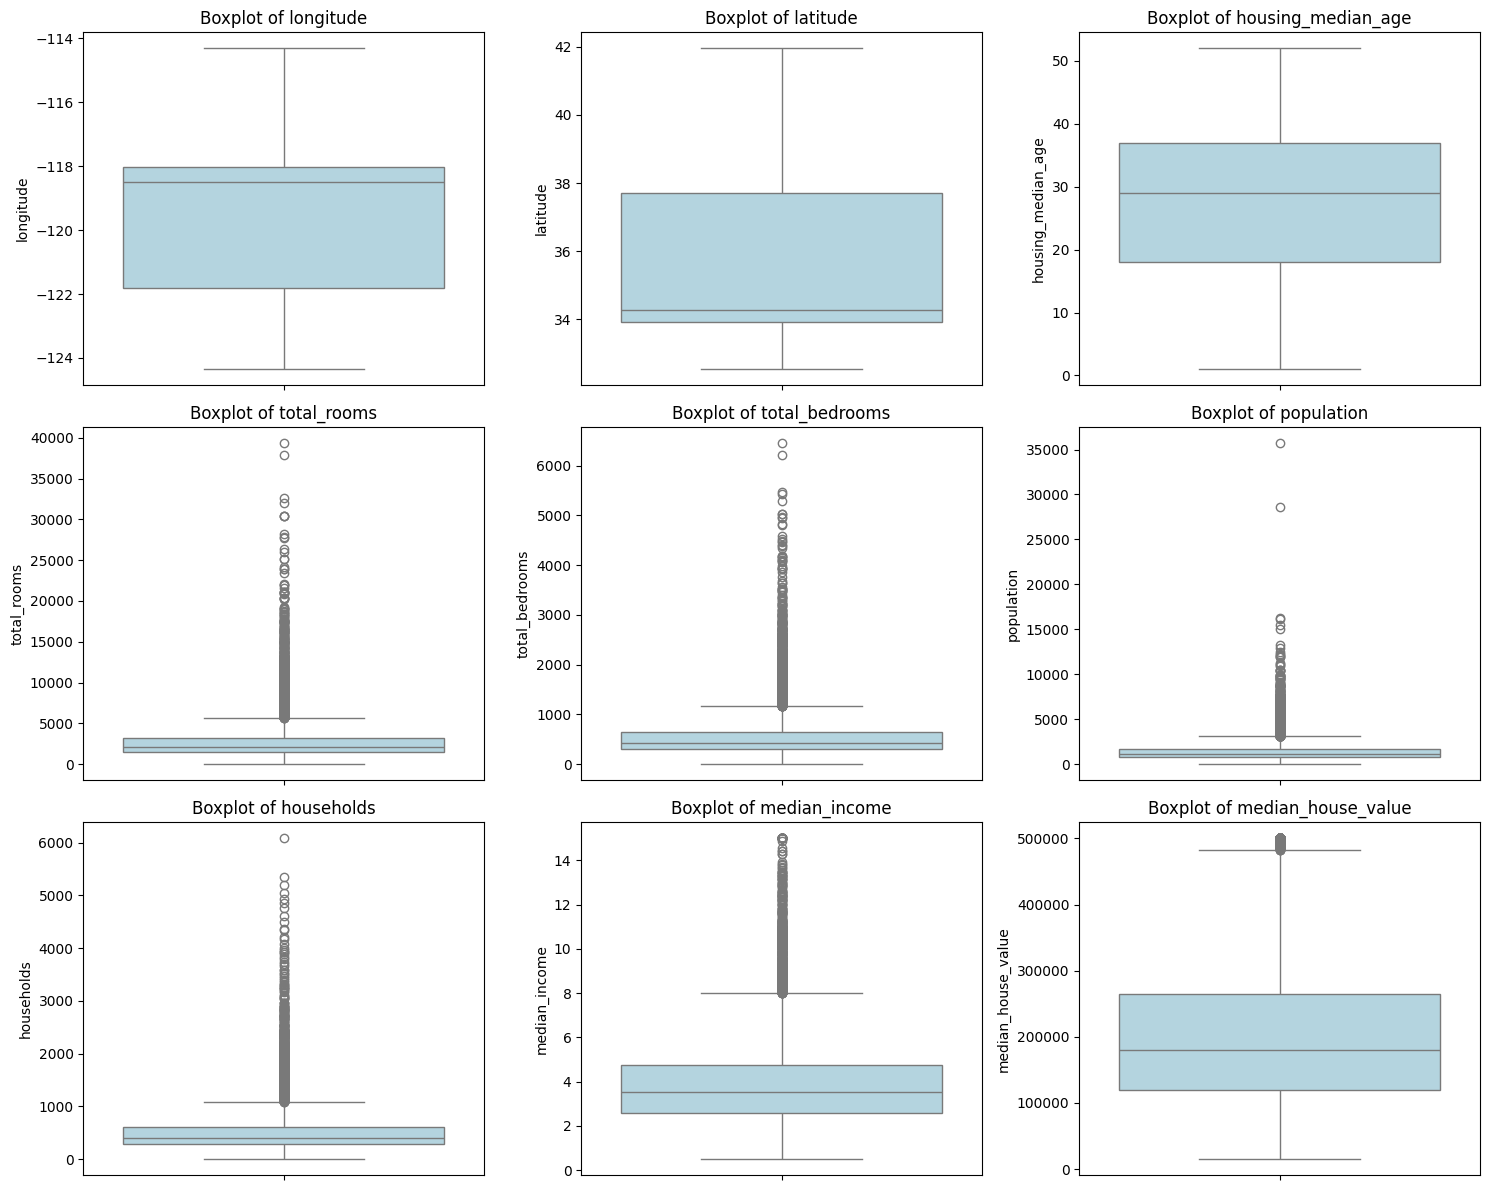

In [15]:
# Create 3x3 subplots for outliers analysis
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


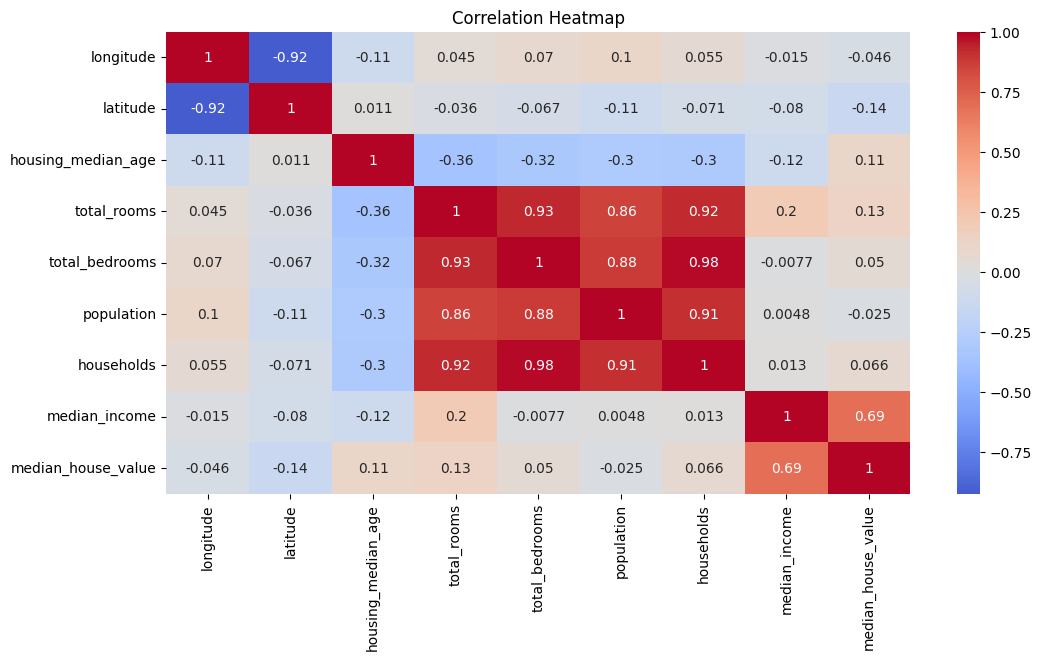

In [17]:
# indentifying the presence of highly corelated columns and feature relationships
plt.figure(figsize=(12,6))
sns.heatmap(df[numerical_cols].corr(),annot=True, cmap='coolwarm',center=0)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
# correlation with target
corr_with_target = df[numerical_cols].corr()[target].sort_values(ascending=False)
print("Correlation with target")
print(corr_with_target.round(3))

Correlation with target
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


> Key Insights from EDA
1. Dataset has numeric + one categorical feature (ocean_proximity)
2. Only total_bedrooms has missing values.
3. Target (median_house_value) is right skewed and capped.
4. Several features shows skew and outliers
5. median_income is the strongest predictor
6. High multicolinearity among rooms and population features

> Preprocessing and Evaluation Plan
1. Median imputation for missing values
2. One-hot encoding for categorical features
3. Feature scaling for linear models
4. Use pipelines to avoid data leakage
5. Baseline model --> CV model selection --> hyperparameter tuning
6. Primary metric: RMSE, secondary: MAE, MSE, R2
7. Final evaluation only on test set

> ## Data Preprocessing

In [27]:
# separating features and target
X = df.drop(columns=[target])
y = df[target]

In [28]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [29]:
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [30]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
print(f"X_train_shape : {X_train.shape}, X_test_shape : {X_test.shape}")
print(f"y_train_shape : {y_train.shape}, X_test : {y_test.shape}")

X_train_shape : (16512, 9), X_test_shape : (4128, 9)
y_train_shape : (16512,), X_test : (4128,)


In [37]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical featurs: ",numerical_features)
print("Categorical featurs: ",categorical_features)

Numerical featurs:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical featurs:  ['ocean_proximity']


In [43]:
# Creating preprocessing pipeline
# Numerical pipeline
numerical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler())
    ]
)

# Categorical pipeline
categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("onehot", OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [44]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
    ("num",numerical_pipe,numerical_features),
    ("cat",categorical_pipe,categorical_features)]
)

> ## Baseline Model (No cross validation, No tuning)

In [45]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",LinearRegression())
    ]
)

In [46]:
# Preprocess the data and train the baseline model
baseline_pipe.fit(X_train,y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


> ## Evaluate the baseline model

In [50]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [51]:
train_rmse = mean_squared_error(y_train, train_baseline_pred)
train_mae = mean_absolute_error(y_train, train_baseline_pred)
train_r2 = r2_score(y_train, train_baseline_pred)

print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)
print("Train R²:", train_r2)



Train RMSE: 4683203783.504252
Train MAE: 49594.842094724365
Train R²: 0.6496648627123224


In [52]:
test_mae = mean_absolute_error(y_test, test_baseline_pred)
test_rmse = mean_squared_error(y_test, test_baseline_pred)
test_r2 = r2_score(y_test, test_baseline_pred)

print("Train RMSE:", test_rmse)
print("Train MAE:", test_mae)
print("Train R²:", test_r2)

Train RMSE: 4908290571.346432
Train MAE: 50670.48923565362
Train R²: 0.6254382675296266
